<a href="https://colab.research.google.com/github/57sg77g8sk-ops/ADALL_github/blob/main/ADALL_Project_Colab_Submission_Final_v4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ADALL Project — Loan Approval Decision Support

**Match Tan** · AI-driven Analytics with Large Language Models

---

### What this notebook does

It trains a model to reproduce a bank's **own past approval decisions**, so the application queue can be
triaged into approve / reject / refer. It is **not** a default-risk model — there is no repayment column
in this dataset.

### How it is organised, and why

Every step is labelled with where it comes from in the module:

| Tag | Meaning |
|---|---|
| **[Week 3]** | Data profiling, cleaning decisions, feature engineering, pipeline, GridSearchCV |
| **[Week 4]** | Baseline comparison, model comparison, cross-validation, error analysis by group, permutation importance |
| **[Week 5]** | Leakage removal, stratified split, judgement writing |
| **[Week 6 S1]** | Classification models, accuracy / F1 / MCC, confusion matrix, FI vs pFI |
| **[Week 6 S2]** | SHAP: TreeExplainer, bar, beeswarm, waterfall |
| **[W1S2 lens]** | One of the six deployment lenses from Week 1 Session 2 |
| **[BEYOND SYLLABUS]** | A technique not covered in class. Each one says why it is needed and what taught idea it extends. |

There are only four **[BEYOND SYLLABUS]** steps and each is justified where it appears.

### Run order

Run the cells from top to bottom. Total runtime is roughly two to three minutes.


## Step 0 · Setup  **[Week 3 / Week 6 S1]**

The imports mirror the Week 6 Session 1 practical, plus `DummyClassifier` from Week 4 and `shap` from Week 6 Session 2.


In [ ]:
!pip -q install xgboost shap

import os, json, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sklearn
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score, f1_score, matthews_corrcoef,
                             confusion_matrix, classification_report,
                             roc_auc_score, brier_score_loss)

from xgboost import XGBClassifier
import xgboost
import shap

warnings.filterwarnings("ignore")
RANDOM_STATE = 42

print("Setup complete")
print("python      :", os.sys.version.split()[0])
print("scikit-learn:", sklearn.__version__)
print("xgboost     :", xgboost.__version__)
print("shap        :", shap.__version__)
print("pandas      :", pd.__version__)
print("numpy       :", np.__version__)

Setup complete
python      : 3.11.15
scikit-learn: 1.8.0
xgboost     : 3.2.0
shap        : 0.51.0
pandas      : 3.0.2
numpy       : 2.4.4


/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Step 1 · Load the data  **[Week 3]**

Change `DATA_URL` to your own GitHub raw URL, exactly as in the Week 3 and Week 4 practicals.
If you are testing locally in Colab, upload the CSV and set `DATA_URL = "loan_approval_dataset.csv"`.


### How to upload `loan_approval_dataset.csv` to Colab:

1.  **Click the 'Files' icon** on the left sidebar (it looks like a folder).
2.  **Click the 'Upload to session storage' icon** (it looks like a page with an upward arrow).
3.  **Select `loan_approval_dataset.csv`** from your local computer and upload it.

Once the file is uploaded, you can run the cell below to load the data.

In [ ]:
import glob # Import the glob module
import os   # Import the os module for os.path.exists

DATA_PATH = ''          # <- optionally paste a full path here

def load_dataset(explicit=''):
    if explicit and os.path.exists(explicit):
        print('Loading from DATA_PATH:', explicit)
        return pd.read_csv(explicit)
    for pattern in ['loan_approval_dataset.csv',
                    '/content/loan_approval_dataset.csv',
                    '/content/**/loan_approval_dataset.csv',
                    '/content/drive/**/loan_approval_dataset.csv']:
        hits = glob.glob(pattern, recursive=True)
        if hits:
            print('Found:', hits[0])
            return pd.read_csv(hits[0])
    try:
        from google.colab import files
        print('Dataset not found — please choose loan_approval_dataset.csv')
        up = files.upload()
        name = next(iter(up))
        return pd.read_csv(name)
    except ImportError:
        raise FileNotFoundError(
            'loan_approval_dataset.csv not found. Set DATA_PATH at the top of this cell.')

df = load_dataset(DATA_PATH)
print('\nShape:', df.shape)
df.head(3)

Found: loan_approval_dataset.csv



Shape: (30000, 36)


,Application_ID,Age,Gender,Marital_Status,Education_Level,Employment_Status,Job_Experience_Years,Annual_Income,Monthly_Income,Credit_Score,...,Co_Applicant,Collateral,Application_Channel,Region,Bank_Account_Age_Years,Previous_Loan_Status,Risk_Score,Default_Risk,Approved_Amount,Loan_Approved
0,500001,26,Female,Single,Bachelor,Contract,5,64389.73,5365.81,584,...,No,No,Branch,South,1.8,Paid Off,68.80,High,34868.81,Approved
1,500002,49,Female,Divorced,Bachelor,Salaried,11,81487.69,6790.64,596,...,Yes,No,Branch,North,10.3,Paid Off,60.24,Medium,77250.62,Approved
2,500003,20,Male,Married,Master,Business Owner,1,96833.02,8069.42,850,...,No,Yes,Agent,North,1.5,Paid Off,30.61,Low,69245.99,Approved


## Step 2 · Dataset profile for LLM review  **[Week 3 / Week 5]**

The payload text from Week 3 Chapter 7. I send the LLM a **summary**, never the full dataset —
it is smaller, cheaper, and avoids sending 30,000 customer records to a third party.


In [ ]:
payload_text = ""
payload_text += "=== SHAPE ===\n"
payload_text += f"Rows: {df.shape[0]}\nColumns: {df.shape[1]}\n\n"

payload_text += "=== COLUMNS AND DATA TYPES ===\n" + df.dtypes.to_string() + "\n\n"
payload_text += "=== NUMERIC SUMMARY ===\n" + df.describe(include="number").round(2).to_string() + "\n\n"

missing_table = pd.DataFrame()
missing_table["missing_count"] = df.isna().sum()
missing_table["missing_pct"] = (df.isna().sum() / len(df) * 100).round(2)
payload_text += "=== MISSING VALUES ===\n" + missing_table.to_string() + "\n\n"

payload_text += "=== UNIQUE VALUES PER COLUMN ===\n" + df.nunique().to_frame("unique_count").to_string() + "\n\n"
payload_text += "=== CORRELATION BETWEEN NUMERIC COLUMNS ===\n" + df.corr(numeric_only=True).round(2).to_string() + "\n\n"

id_like = df.columns[df.nunique() == len(df)].tolist()
payload_text += "=== POSSIBLE UNIQUE-ID COLUMNS ===\n" + str(id_like) + "\n"

print(payload_text[:2500])
print("...")
print("payload length:", len(payload_text), "characters")

=== SHAPE ===
Rows: 30000
Columns: 36

=== COLUMNS AND DATA TYPES ===
Application_ID                  int64
Age                             int64
Gender                            str
Marital_Status                    str
Education_Level                   str
Employment_Status                 str
Job_Experience_Years            int64
Annual_Income                 float64
Monthly_Income                float64
Credit_Score                    int64
Credit_History_Years          float64
Existing_Loans                  int64
Late_Payments_Last_2_Years      int64
Loan_Amount                   float64
Loan_Term_Months                int64
Loan_Purpose                      str
Interest_Rate                 float64
Debt_To_Income_Ratio          float64
Savings_Balance               float64
Checking_Balance              float64
Total_Assets                  float64
Total_Liabilities             float64
Monthly_Debt_Payment          float64
Property_Ownership                str
Residential_Status

### The prompt I sent, and the four faults I found in the answer

I asked an LLM for the business problem, persona and job-to-be-done. Its answer and my critique are on
**slide 4** of the deck. In short:

1. **Wrong target.** It proposed predicting *default*. There is no repayment column in this dataset.
2. **Two of its predictors leak.** It recommended `Risk_Score` and `Default_Risk`, both created *during* assessment.
3. **Wrong success measure.** It asked for "accuracy above 90%". Step 6 below shows why that is a trap here.
4. **The persona was a job title**, with no authority and no volumes, so it constrained nothing.

The lesson from Week 5: *the LLM recommendation is not automatically correct — you still decide.*


In [ ]:
llm_prompt = f"""
I am building a model on a bank loan dataset. The target column is Loan_Approved.

Dataset profile:
{payload_text}

Answer in three sections:
1. Data quality issues to check before modelling.
2. Columns that may cause leakage, with reasons.
3. Which of your recommendations need human judgement before I apply them.

Do not write modelling code yet.
"""
print(llm_prompt[:900])
print("\n... (paste this into the approved LLM tool; my critique of its answer is in the report)")


I am building a model on a bank loan dataset. The target column is Loan_Approved.

Dataset profile:
=== SHAPE ===
Rows: 30000
Columns: 36

=== COLUMNS AND DATA TYPES ===
Application_ID                  int64
Age                             int64
Gender                            str
Marital_Status                    str
Education_Level                   str
Employment_Status                 str
Job_Experience_Years            int64
Annual_Income                 float64
Monthly_Income                float64
Credit_Score                    int64
Credit_History_Years          float64
Existing_Loans                  int64
Late_Payments_Last_2_Years      int64
Loan_Amount                   float64
Loan_Term_Months                int64
Loan_Purpose                      str
Interest_Rate                 float64
Debt_To_Income_Ratio          float64
Savings_Balance               float64
Checkin

... (paste this into the approved LLM tool; my critique of its answer is in the report)


## Step 3 · Data quality checks  **[Week 3]**  · **[W1S2 lens 3: Data quality]**

Week 3's rule: *warnings are not automatic actions.* I run the checks first, then decide.


In [ ]:
TARGET_COL = "Loan_Approved"

print("Rows                :", f"{df.shape[0]:,}")
print("Columns             :", df.shape[1])
print("Missing values      :", df.isna().sum().sum())
print("Duplicate rows      :", df.duplicated().sum())
print("Duplicate IDs       :", df["Application_ID"].duplicated().sum())
print()
print("Target balance:")
print(df[TARGET_COL].value_counts())
print((df[TARGET_COL].value_counts(normalize=True) * 100).round(2))

# A redundancy the profile hints at but does not prove -- so I test it directly.
gap = (df["Annual_Income"] - 12 * df["Monthly_Income"]).abs().max()
print()
print("Largest gap between Annual_Income and 12 x Monthly_Income:", round(gap, 4))
print("=> they are the same column twice. I keep Monthly_Income and drop Annual_Income.")

Rows                : 30,000
Columns             : 36
Missing values      : 0
Duplicate rows      : 0
Duplicate IDs       : 0

Target balance:
Loan_Approved
Approved    17291
Rejected    12709
Name: count, dtype: int64
Loan_Approved
Approved    57.64
Rejected    42.36
Name: proportion, dtype: float64

Largest gap between Annual_Income and 12 x Monthly_Income: 0.06
=> they are the same column twice. I keep Monthly_Income and drop Annual_Income.


**Decision, written out (Week 5 style):**

> The dataset has 30,000 rows and 36 columns with no missing values, no duplicate rows and no duplicate IDs,
> so no filling-in or de-duplication step is needed and adding one would be padding. The target is split
> 57.6 / 42.4, which is only mildly uneven, so I do **not** rebalance — synthesising extra rows would change
> the approval rate that my entire recommendation is calibrated against. I use a stratified split instead.
> `Annual_Income` is exactly twelve times `Monthly_Income`, so I drop one of them.


## Step 4 · Target leakage  **[Week 5]** · **[W1S2 lens 5: Timeline]**

Week 5 removed `G1`, `G2`, `G3` because the target was *calculated* from them.
Here the leakage is subtler — the columns are not used to build the target, they are **written down after
the decision has already been made**.

The test comes straight from the Week 1 Session 2 Timeline lens:

> *"Will all the necessary inputs for the model be accessible when the output is requested?"*

The job says the score is needed **when the application lands**. So I asked that of every column.

*Deck: body slide 6 — the MCC 1.000 result is row 1 of the Step 7 table.*


In [ ]:
LEAK_COLS = ["Approved_Amount", "Risk_Score", "Default_Risk", "Interest_Rate"]

y = (df[TARGET_COL] == "Approved").astype(int)

# Evidence 1: Approved_Amount IS the decision, written as a number.
print(df.groupby(TARGET_COL)["Approved_Amount"].agg(
    mean="mean", minimum="min", maximum="max", n_zero=lambda s: (s == 0).sum()).round(2))
print()

# Evidence 2: Default_Risk is an assessment grade, not an applicant attribute.
print((pd.crosstab(df["Default_Risk"], df[TARGET_COL], normalize="index") * 100).round(1))

                   mean  minimum    maximum  n_zero
Loan_Approved                                      
Approved       93412.26   1000.0  393109.69       0
Rejected           0.00      0.0       0.00   12709

Loan_Approved  Approved  Rejected
Default_Risk                     
High                4.9      95.1
Low                96.3       3.7
Medium             58.3      41.7


In [ ]:
# Evidence 3: how strong is each column ON ITS OWN?
# [BEYOND SYLLABUS] single-column AUC. Justification: the timing test above is the real
# argument and it is taught. This is only supporting evidence -- it quantifies how
# implausible a hand-entered column is. Nothing is dropped on the strength of this alone.
def single_column_strength(col):
    s = df[col]
    if s.dtype.kind in "biufc":
        a = roc_auc_score(y, s)
    else:
        a = roc_auc_score(y, y.groupby(s).transform("mean"))
    return round(max(a, 1 - a), 3)

for c in ["Approved_Amount", "Risk_Score", "Credit_Score", "Interest_Rate",
          "Debt_To_Income_Ratio", "Loan_Amount"]:
    flag = "  <-- REMOVED, written after the decision" if c in LEAK_COLS else ""
    print(f"{c:24s} {single_column_strength(c):.3f}{flag}")

Approved_Amount          1.000  <-- REMOVED, written after the decision
Risk_Score               0.925  <-- REMOVED, written after the decision
Credit_Score             0.772
Interest_Rate            0.702  <-- REMOVED, written after the decision
Debt_To_Income_Ratio     0.669
Loan_Amount              0.567


**Decision:**

> I removed `Approved_Amount`, `Risk_Score`, `Default_Risk` and `Interest_Rate` because none of them exists
> at the moment the application lands. `Approved_Amount` is $0 on all 12,709 declined files and never $0 on an
> approved one — it *is* the decision. A model using these four columns is useless in the one place it would
> run, because the officer opening the file would see blanks. I also hold `Gender` out of the model entirely
> and keep it only for the fairness check in Step 12.

Step 7 measures exactly what removing them costs: its first row is this same model with the four columns
still in, so the gap between rows 1 and 2 of that table is the price of the audit.


## Step 5 · Feature engineering  **[Week 3]**

Week 3 built an `engineered_df` and compared it against the baseline model. Same idea here.
Three changes, each mirroring how a credit officer actually thinks.


In [ ]:
def build_features(d):
    o = d.copy()
    annual  = o["Monthly_Income"] * 12
    monthly = o["Monthly_Income"]
    instalment = o["Loan_Amount"] / o["Loan_Term_Months"]

    # 1. RATIOS -- credit is judged against income, not in absolute dollars
    o["Loan_To_Income"]         = o["Loan_Amount"] / annual
    o["Instalment_To_Income"]   = instalment / monthly
    o["Total_Obligation_Ratio"] = (instalment + o["Monthly_Debt_Payment"]) / monthly
    o["Cash_Buffer_Months"]     = (o["Savings_Balance"] + o["Checking_Balance"]) / monthly
    o["Leverage"]               = (o["Total_Liabilities"] / o["Total_Assets"].replace(0, np.nan)).fillna(0)
    o["Credit_History_Depth"]   = o["Credit_History_Years"] / (o["Age"] - 18).clip(lower=1)
    o["Net_Worth"]              = o["Total_Assets"] - o["Total_Liabilities"]
    o["Any_Late_Payment"]       = (o["Late_Payments_Last_2_Years"] > 0).astype(int)

    # 2. GROUP CATEGORIES BY BEHAVIOUR, not by name
    purpose_group = {"Car": "Secured asset", "Home": "Secured asset",
                     "Business": "Income generating", "Education": "Income generating",
                     "Debt Consolidation": "Refinancing",
                     "Personal": "Consumption", "Medical": "Consumption"}
    o["Loan_Purpose_Grouped"]   = o["Loan_Purpose"].map(purpose_group)
    o["Marital_Status_Grouped"] = o["Marital_Status"].replace(
        {"Divorced": "Previously married", "Widowed": "Previously married"})
    o["Education_Grouped"]      = o["Education_Level"].replace(
        {"Master": "Postgraduate", "PhD": "Postgraduate"})

    # 3. LOG SQUASH on the lopsided money and ratio columns
    # [BEYOND SYLLABUS] log1p. Justification: W2S1's checklist asks us to "inspect ranges,
    # skewness, outliers". These columns are skewed 1.1 to 2.4. log1p rather than log
    # because savings and repayments can genuinely be zero. Step 7 measures whether it helped.
    for c in ["Debt_To_Income_Ratio", "Monthly_Debt_Payment", "Total_Liabilities",
              "Loan_Amount", "Savings_Balance", "Loan_To_Income", "Instalment_To_Income",
              "Total_Obligation_Ratio", "Cash_Buffer_Months"]:
        o[c] = np.log1p(o[c].clip(lower=0))
    return o

print("Skewness of the columns I squash:")
print(df[["Debt_To_Income_Ratio", "Monthly_Debt_Payment", "Late_Payments_Last_2_Years",
          "Total_Liabilities", "Loan_Term_Months", "Existing_Loans",
          "Credit_Score"]].skew().round(2).to_string())

engineered_df = build_features(df)
print("\nengineered_df:", engineered_df.shape)

Skewness of the columns I squash:
Debt_To_Income_Ratio          2.44
Monthly_Debt_Payment          2.37
Late_Payments_Last_2_Years    2.05
Total_Liabilities             1.28
Loan_Term_Months              1.27
Existing_Loans                1.09
Credit_Score                 -0.20



engineered_df: (30000, 47)


## Step 6 · Split and preprocessing pipeline  **[Week 5 / Week 6 S1]**

`stratify=y` so the 57.6 / 42.4 balance is the same in both halves. One split, `random_state=42`,
and the test set is touched only for final reporting.


In [ ]:
DROP = (["Application_ID", TARGET_COL] + LEAK_COLS +
        ["Gender",                                   # held out for the fairness check only
         "Annual_Income",                            # exact duplicate of 12 x Monthly_Income
         "Loan_Purpose", "Marital_Status", "Education_Level"])  # replaced by grouped versions

X = engineered_df.drop(columns=DROP)
y = (engineered_df[TARGET_COL] == "Approved").astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

num_cols = X_train.select_dtypes(exclude=["object", "string", "category"]).columns.tolist()
cat_cols = [c for c in X_train.columns if c not in num_cols]

preprocessor = ColumnTransformer(transformers=[
    ("num", "passthrough", num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)])

print("X_train:", X_train.shape, " X_test:", X_test.shape)
print("Numeric columns    :", len(num_cols))
print("Categorical columns:", len(cat_cols))
print()
print("Train approval rate:", round(y_train.mean() * 100, 2), "%")
print("Test approval rate :", round(y_test.mean() * 100, 2), "%")

X_train: (24000, 36)  X_test: (6000, 36)
Numeric columns    : 25
Categorical columns: 11

Train approval rate: 57.64 %
Test approval rate : 57.63 %


## Step 7 · Did the feature engineering help?  **[Week 3]**

Week 3 compared a baseline model against an engineered one. Same model, same split, same settings —
only the columns change.


In [ ]:
def score_columns(X_variant, label):
    a, b, c, d = train_test_split(X_variant, y, test_size=0.2,
                                  random_state=RANDOM_STATE, stratify=y)
    n = a.select_dtypes(exclude=["object", "string", "category"]).columns.tolist()
    k = [x for x in a.columns if x not in n]
    pipe = Pipeline([
        ("preprocessor", ColumnTransformer([("num", "passthrough", n),
                                            ("cat", OneHotEncoder(handle_unknown="ignore"), k)])),
        ("model", XGBClassifier(n_estimators=150, max_depth=3, learning_rate=0.08,
                                subsample=0.9, colsample_bytree=0.9,
                                random_state=RANDOM_STATE, eval_metric="logloss", n_jobs=1))])
    pipe.fit(a, c)
    pred = pipe.predict(b)
    return {"variant": label,
            "MCC": round(matthews_corrcoef(d, pred), 4),
            "accuracy": round(accuracy_score(d, pred), 4),
            "F1": round(f1_score(d, pred), 4)}

# Three variants, same model / split / settings -- only the columns change.
# Row 1 is the model BEFORE the leakage audit of Step 4: it is what a perfect-looking
# score actually is. Rows 2 and 3 are the honest models.
X_with_leaks = df.drop(columns=["Application_ID", TARGET_COL, "Gender"])   # leaked columns still in
X_raw_only   = df.drop(columns=["Application_ID", TARGET_COL] + LEAK_COLS + ["Gender"])

comparison = pd.DataFrame([score_columns(X_with_leaks, "With the 4 leaked columns"),
                           score_columns(X_raw_only,   "Raw supplied columns"),
                           score_columns(X,            "Engineered columns")])
print("Cost of removing the leaked columns:",
      round(comparison.loc[0, "MCC"] - comparison.loc[1, "MCC"], 4), "MCC")
print("Gain from feature engineering      :",
      round(comparison.loc[2, "MCC"] - comparison.loc[1, "MCC"], 4), "MCC")
comparison

Cost of removing the leaked columns: 0.3926 MCC
Gain from feature engineering      : 0.0195 MCC


,variant,MCC,accuracy,F1
0,With the 4 leaked columns,1.0000,1.0000,1.0000
1,Raw supplied columns,0.6074,0.8097,0.8402
2,Engineered columns,0.6269,0.8190,0.8478


**Reading the three rows.**

**Row 1 is the number the deck opens the leakage story with.** With `Approved_Amount`, `Risk_Score`,
`Default_Risk` and `Interest_Rate` still in, the model scores an essentially perfect MCC. That is not
performance — it is the model reading the answer off the file. The drop from row 1 to row 2 is exactly
what the leakage audit in Step 4 cost, and it is the single most important number in this project.

**Rows 2 to 3** are the honest comparison: the engineered columns gain about 0.02 of MCC. That is small,
but it is several times the fold-to-fold spread I see in Step 8, so it is a real gain rather than
run-to-run noise.

The honest caveat: the affordability columns overlap heavily with one another (checked below). That does not
hurt a tree's accuracy, but it does spread the "affordability" signal across several columns, so I read the
SHAP results at group level rather than pretending one column owns the whole effect.


In [ ]:
# The Week 3 correlation check, pointed at the six affordability columns.
AFFORDABILITY = ["Loan_To_Income", "Instalment_To_Income", "Total_Obligation_Ratio",
                 "Debt_To_Income_Ratio", "Monthly_Debt_Payment", "Loan_Amount"]
corr = engineered_df[AFFORDABILITY].corr().round(2)
print("Highest off-diagonal correlation:",
      round(corr.where(~np.eye(len(AFFORDABILITY), dtype=bool)).abs().max().max(), 3))
corr

Highest off-diagonal correlation: 0.97


,Loan_To_Income,Instalment_To_Income,Total_Obligation_Ratio,Debt_To_Income_Ratio,Monthly_Debt_Payment,Loan_Amount
Loan_To_Income,1.00,0.44,0.51,0.53,0.52,0.81
Instalment_To_Income,0.44,1.00,0.97,0.23,0.22,0.35
Total_Obligation_Ratio,0.51,0.97,1.00,0.42,0.38,0.38
Debt_To_Income_Ratio,0.53,0.23,0.42,1.00,0.88,0.35
Monthly_Debt_Payment,0.52,0.22,0.38,0.88,1.00,0.60
Loan_Amount,0.81,0.35,0.38,0.35,0.60,1.00


## Step 8 · Four models, and the first one is deliberately stupid  **[Week 4 Ch.13 / Week 6 S1]**

Week 4 Chapter 13: *"A model should beat a very simple baseline… If the machine learning model is only
slightly better than this, the model may not be worth deploying."*

For classification the equivalent of the mean-price baseline is `DummyClassifier(strategy="most_frequent")` —
it approves every single application. The other three models and their settings are the Week 6 Session 1 practical.


In [ ]:
models = {
    "Always approve (baseline)": DummyClassifier(strategy="most_frequent"),
    "Decision Tree": DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=150, random_state=RANDOM_STATE, n_jobs=-1),
    "XGBoost": XGBClassifier(n_estimators=150, max_depth=3, learning_rate=0.08,
                             subsample=0.9, colsample_bytree=0.9,
                             random_state=RANDOM_STATE, eval_metric="logloss", n_jobs=1),
}

fitted, rows = {}, []
for name, model in models.items():
    pipe = Pipeline([("preprocessor", preprocessor), ("model", model)])
    t0 = time.time(); pipe.fit(X_train, y_train); fit_seconds = time.time() - t0

    pred  = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]
    cv    = cross_val_score(pipe, X_train, y_train, cv=5,
                            scoring="matthews_corrcoef", n_jobs=-1)
    fitted[name] = pipe
    rows.append({"model": name,
                 "cv_mcc": cv.mean(), "cv_std": cv.std(),
                 "MCC": matthews_corrcoef(y_test, pred),
                 "accuracy": accuracy_score(y_test, pred),
                 "F1": f1_score(y_test, pred),
                 "AUC*": roc_auc_score(y_test, proba),
                 "Brier*": brier_score_loss(y_test, proba),
                 "fit_s": fit_seconds})

results = pd.DataFrame(rows).round(4)
results

,model,cv_mcc,cv_std,MCC,accuracy,F1,AUC*,Brier*,fit_s
0,Always approve (baseline),0.0000,0.0000,0.0000,0.5763,0.7312,0.5000,0.4237,0.0461
1,Decision Tree,0.5297,0.0083,0.5340,0.7747,0.8137,0.8295,0.1596,0.2946
2,Random Forest,0.6062,0.0140,0.6034,0.8077,0.8379,0.8861,0.1370,5.0285
3,XGBoost,0.6257,0.0097,0.6269,0.8190,0.8478,0.8966,0.1273,0.5602


**This is the row that matters.** "Always approve" gets **57.6% accuracy** — which sounds respectable —
while scoring **MCC exactly 0.000**, because it never gets a single rejection right.

That is the whole argument for MCC over accuracy on an uneven split, and it is why the LLM's
"accuracy above 90%" success measure was wrong. It is also the bar every other model has to clear.

`AUC` and `Brier` are marked with `*` because they are **[BEYOND SYLLABUS]** — see Step 11 for why I need them.
The module's classification metrics are accuracy, F1 and MCC, and those are what I judge on.


## Step 9 · Confusion matrix and classification report  **[Week 6 S1]**

An average score does not tell you *which* mistake the model makes. For a bank the two errors have very
different costs.


In [ ]:
best_name = "XGBoost"
best_model = fitted[best_name]
pred = best_model.predict(X_test)
proba = best_model.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, pred)
print("Confusion matrix (rows = actual, columns = predicted):")
print(pd.DataFrame(cm,
                   index=["Actually rejected", "Actually approved"],
                   columns=["Predicted rejected", "Predicted approved"]))
print()
print(classification_report(y_test, pred, target_names=["Rejected", "Approved"]))
print(f"Files the model would approve that the bank declined: {cm[0,1]:,}  <- the expensive mistake")
print(f"Files the model would decline that the bank approved: {cm[1,0]:,}")

Confusion matrix (rows = actual, columns = predicted):
                   Predicted rejected  Predicted approved
Actually rejected                1890                 652
Actually approved                 434                3024

              precision    recall  f1-score   support

    Rejected       0.81      0.74      0.78      2542
    Approved       0.82      0.87      0.85      3458

    accuracy                           0.82      6000
   macro avg       0.82      0.81      0.81      6000
weighted avg       0.82      0.82      0.82      6000

Files the model would approve that the bank declined: 652  <- the expensive mistake
Files the model would decline that the bank approved: 434


## Step 10 · Tuning check  **[Week 3 GridSearchCV]**

Week 3 used `GridSearchCV`. I run it here for one reason only: to show XGBoost did not win because I
tuned it harder than the others. Note the result — the tuned model wins in cross-validation and then
**loses on the held-out test set**, which is textbook over-fitting to the validation folds.


In [ ]:
grid = GridSearchCV(
    Pipeline([("preprocessor", preprocessor),
              ("model", XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss", n_jobs=1))]),
    param_grid={"model__max_depth": [3, 4, 5],
                "model__learning_rate": [0.05, 0.08, 0.2],
                "model__n_estimators": [150, 300]},
    cv=5, scoring="matthews_corrcoef", n_jobs=-1)

grid.fit(X_train, y_train)

print("Best parameters :", grid.best_params_)
print("Best CV MCC     :", round(grid.best_score_, 4),
      " vs my settings:", round(results.loc[results.model == 'XGBoost', 'cv_mcc'].iloc[0], 4))
print("Tuned TEST MCC  :", round(matthews_corrcoef(y_test, grid.best_estimator_.predict(X_test)), 4),
      " vs my settings:", round(results.loc[results.model == 'XGBoost', 'MCC'].iloc[0], 4))
print()
print("=> the tuned model is better in CV and worse on the test set, so I keep the simpler settings.")

Best parameters : {'model__learning_rate': 0.05, 'model__max_depth': 5, 'model__n_estimators': 300}
Best CV MCC     : 0.6266  vs my settings: 0.6257
Tuned TEST MCC  : 0.6172  vs my settings: 0.6269

=> the tuned model is better in CV and worse on the test set, so I keep the simpler settings.


## Step 11 · What the model relies on, checked three ways  **[Week 4 Ch.20 / Week 6 S1 Ch.7-9 / Week 6 S2]**

Week 6 Session 1 Chapter 9 asks explicitly whether Feature Importance and Permutation Feature Importance
agree. Week 6 Session 2 adds SHAP. Running all three is not padding — **agreement between methods that
ask different questions is evidence.**


In [ ]:
# (a) Feature importance from the Random Forest  [Week 6 S1 Ch.7]
feature_names = [n.replace("num__", "").replace("cat__", "")
                 for n in best_model.named_steps["preprocessor"].get_feature_names_out()]
rf_fi = pd.DataFrame({
    "feature": feature_names,
    "rf_importance": fitted["Random Forest"].named_steps["model"].feature_importances_
}).sort_values("rf_importance", ascending=False)

# (b) Permutation importance on the champion model  [Week 4 Ch.20 / Week 6 S1 Ch.8]
pfi = permutation_importance(best_model, X_test, y_test, n_repeats=5,
                             random_state=RANDOM_STATE, scoring="matthews_corrcoef", n_jobs=-1)
pfi_df = pd.DataFrame({"feature": X_test.columns,
                       "mcc_drop_when_shuffled": pfi.importances_mean,
                       "std": pfi.importances_std}).sort_values("mcc_drop_when_shuffled",
                                                                ascending=False)
print("Top 8 by Random Forest feature importance:")
print(rf_fi.head(8).to_string(index=False))
print()
print("Top 8 by permutation importance (champion model):")
print(pfi_df.head(8).round(4).to_string(index=False))

Top 8 by Random Forest feature importance:
                       feature  rf_importance
                  Credit_Score       0.145512
                Loan_To_Income       0.064131
          Debt_To_Income_Ratio       0.047494
    Late_Payments_Last_2_Years       0.043120
               Savings_Balance       0.042440
Previous_Loan_Status_Defaulted       0.036202
                      Leverage       0.032139
            Cash_Buffer_Months       0.031364

Top 8 by permutation importance (champion model):
                   feature  mcc_drop_when_shuffled    std
              Credit_Score                  0.2191 0.0081
      Previous_Loan_Status                  0.0989 0.0041
            Loan_To_Income                  0.0968 0.0025
         Employment_Status                  0.0451 0.0031
Late_Payments_Last_2_Years                  0.0363 0.0056
      Debt_To_Income_Ratio                  0.0344 0.0031
                Collateral                  0.0214 0.0033
            Existing_Loans  

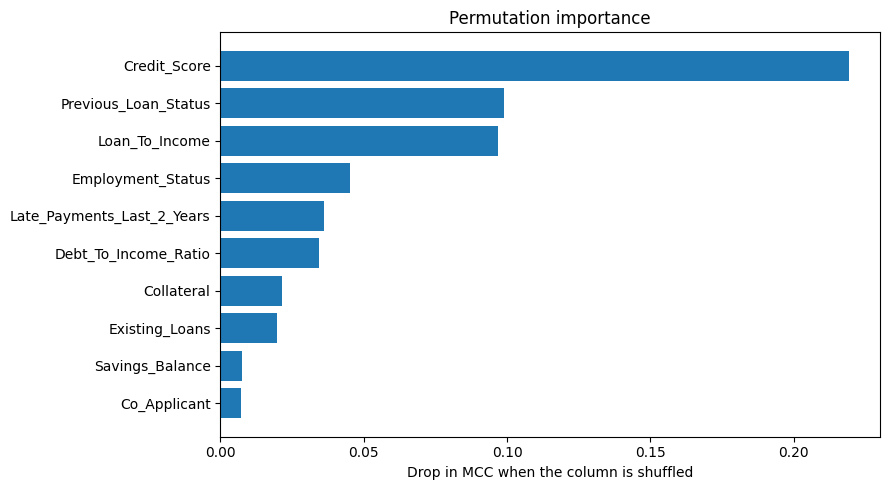

In [ ]:
plt.figure(figsize=(9, 5))
top = pfi_df.head(10).sort_values("mcc_drop_when_shuffled")
plt.barh(top["feature"], top["mcc_drop_when_shuffled"])
plt.xlabel("Drop in MCC when the column is shuffled")
plt.title("Permutation importance")
plt.tight_layout(); plt.show()

**Written answer (Week 6 S1 template):**

> The top FI features are credit score and loan to income. The top pFI features are credit score, previous
> loan status and loan to income. The results are mostly consistent, which suggests the model genuinely
> relies on credit score and loan-to-income rather than on an artefact of one method.
> However, this is model explanation, not proof of cause.


### SHAP: bar, beeswarm, waterfall  **[Week 6 S2]**

`feature_importances_` and permutation importance both tell you **how much** a column matters.
Neither tells you **which way** it pushes. That is what SHAP adds.


In [ ]:
X_test_encoded = best_model.named_steps["preprocessor"].transform(X_test)
if hasattr(X_test_encoded, "toarray"):
    X_test_encoded = X_test_encoded.toarray()
X_test_encoded = pd.DataFrame(X_test_encoded, columns=feature_names, index=X_test.index)

explainer   = shap.TreeExplainer(best_model.named_steps["model"])
shap_values = explainer(X_test_encoded)

print("Rows explained  :", X_test_encoded.shape[0])
print("SHAP values shape:", shap_values.values.shape)

mean_abs = pd.Series(np.abs(shap_values.values).mean(axis=0),
                     index=feature_names).sort_values(ascending=False)
print()
print("Share of all pushing carried by the top three columns:",
      round(100 * mean_abs.head(3).sum() / mean_abs.sum(), 1), "%")

Rows explained  : 6000
SHAP values shape: (6000, 64)

Share of all pushing carried by the top three columns: 44.1 %


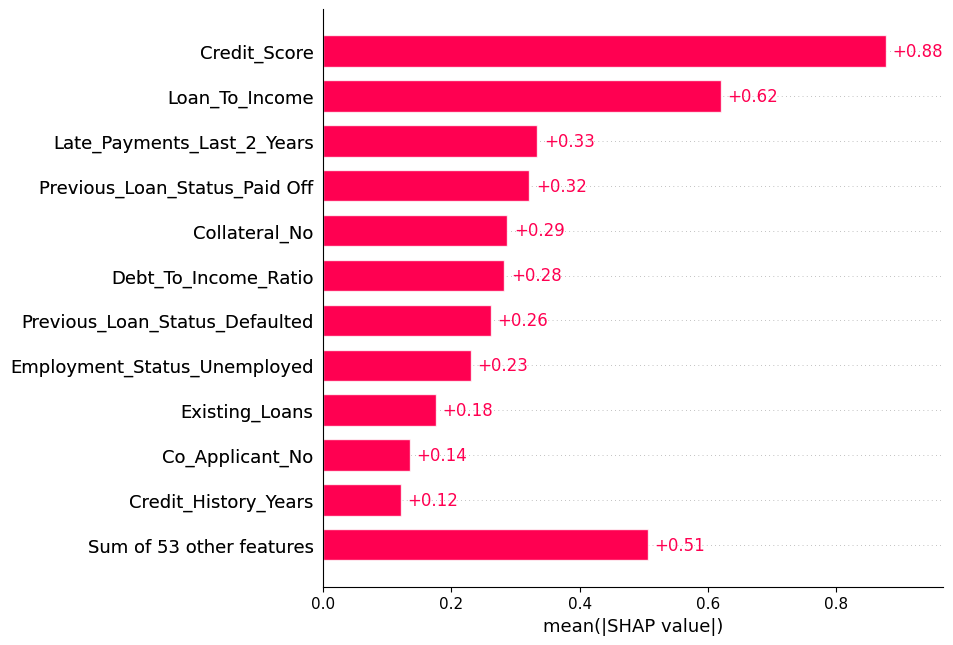

In [ ]:
shap.plots.bar(shap_values, max_display=12)

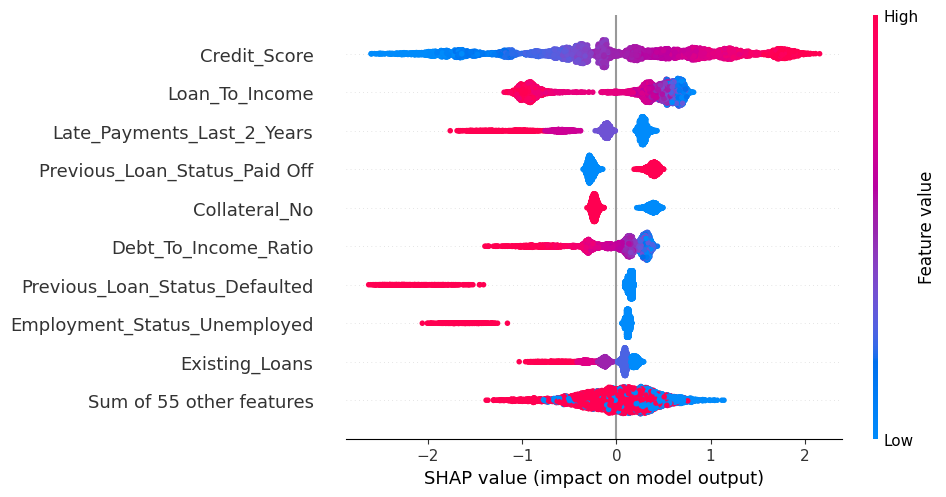

In [ ]:
shap.plots.beeswarm(shap_values, max_display=10)

### Step 11c · The two charts exactly as they appear in the deck  **[presentation]**

The plots above are the raw library defaults. The deck uses the same numbers with readable labels and a
written title. This cell is the *only* source of the slide-10 image — re-run it and re-paste if any
number moves, so the deck can never drift from the notebook again.


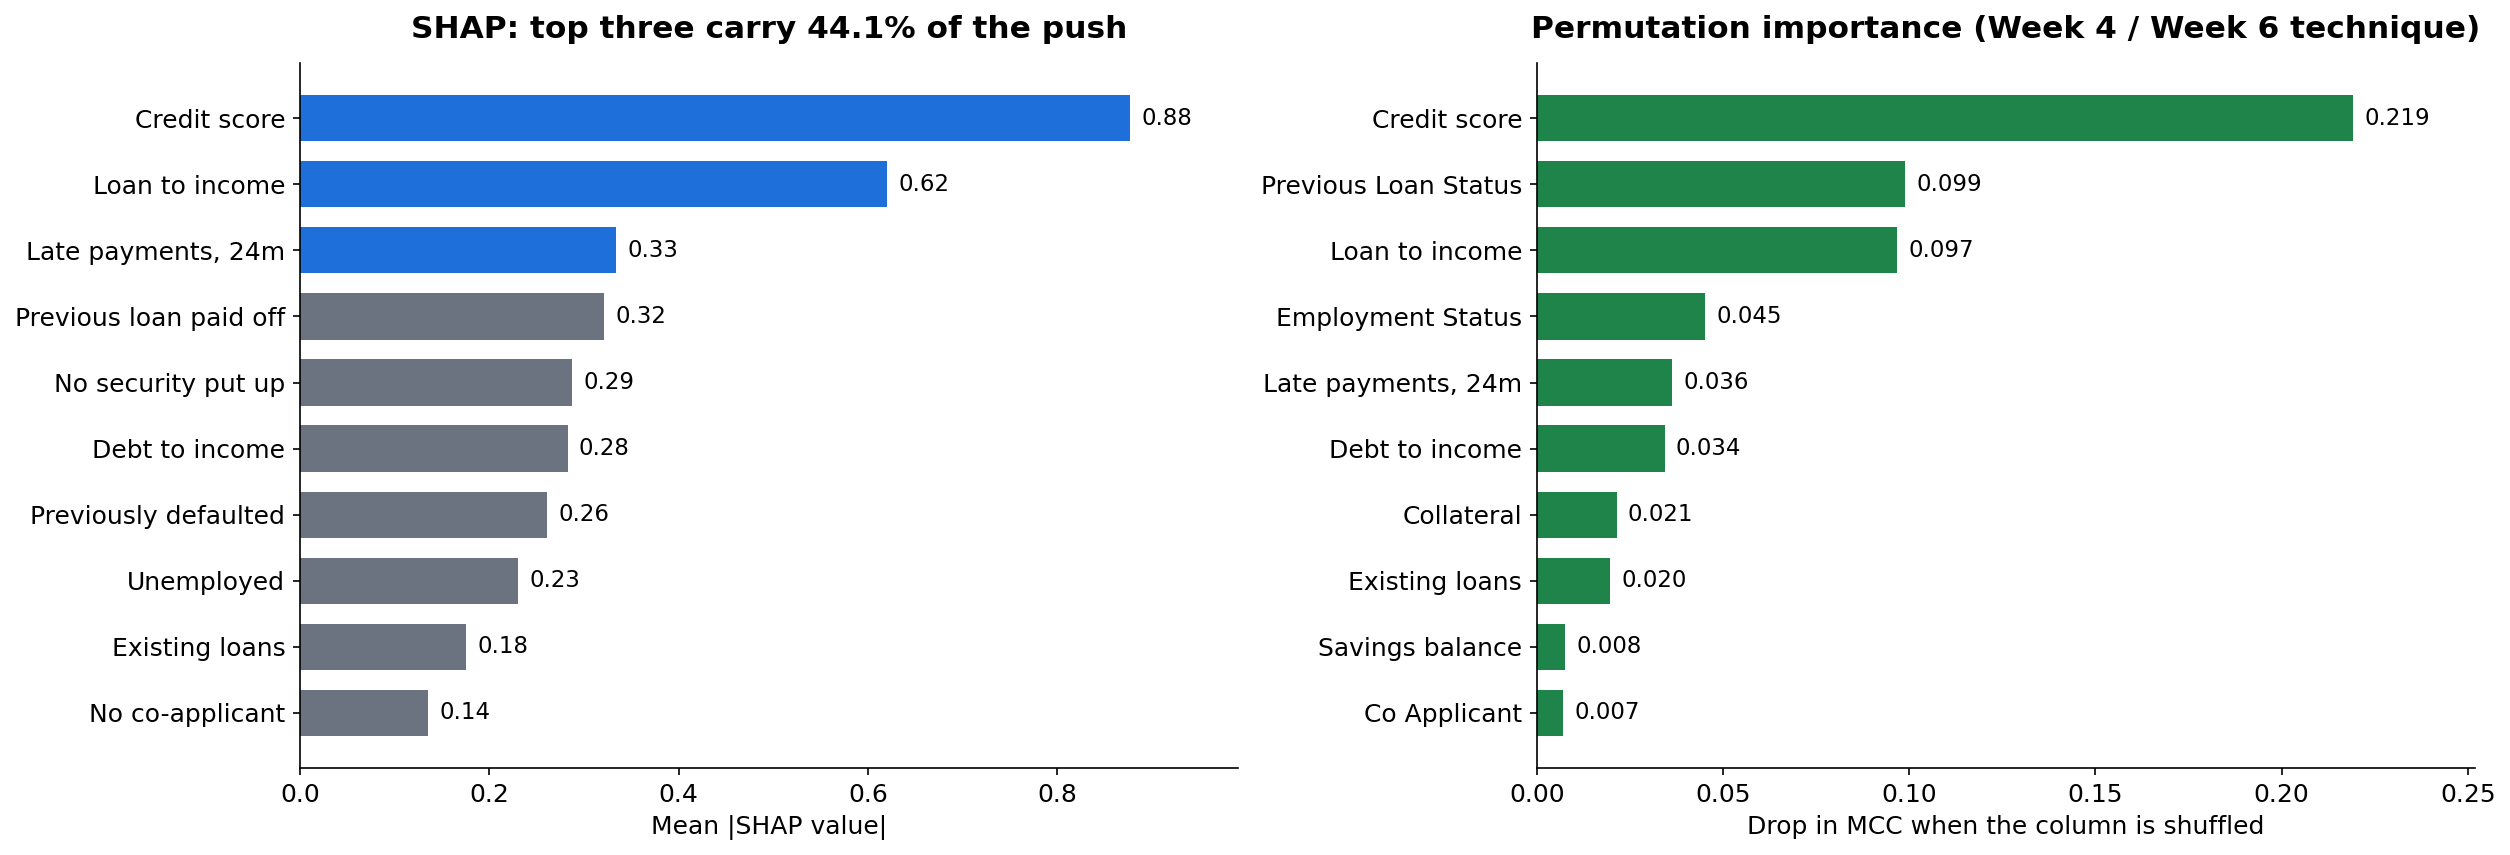

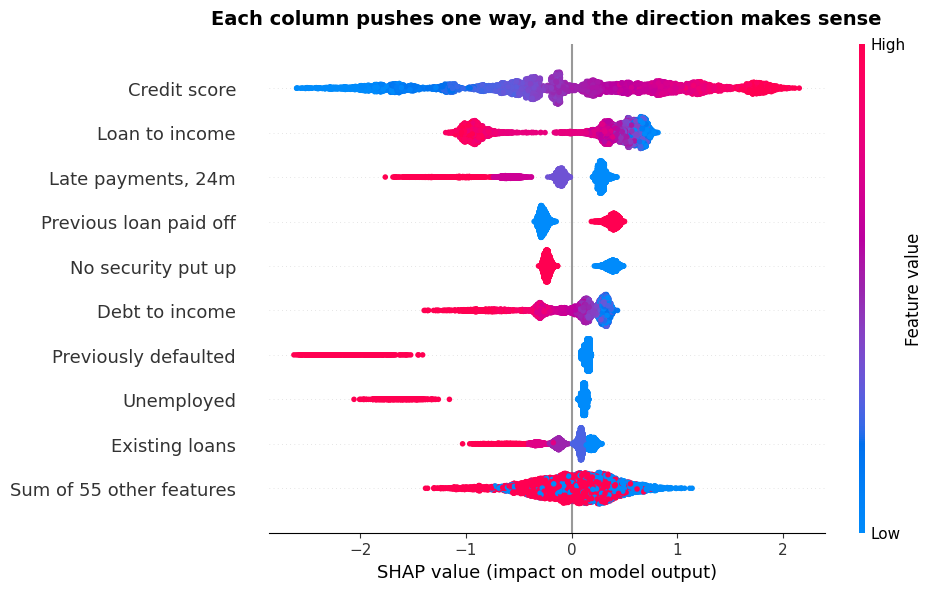

Deck images written. Slide-10 title reads: top three carry 44.1% of the push


In [ ]:
# --- the deck version of the two importance charts (slide 10) ---
BLUE, GREY, GREEN = "#1E6FD9", "#6B7280", "#1E8449"
NICE = {"Credit_Score":"Credit score", "Loan_To_Income":"Loan to income",
        "Late_Payments_Last_2_Years":"Late payments, 24m",
        "Previous_Loan_Status_Paid Off":"Previous loan paid off",
        "Collateral_No":"No security put up", "Debt_To_Income_Ratio":"Debt to income",
        "Previous_Loan_Status_Defaulted":"Previously defaulted",
        "Employment_Status_Unemployed":"Unemployed", "Existing_Loans":"Existing loans",
        "Co_Applicant_No":"No co-applicant", "Credit_History_Years":"Credit history, years",
        "Savings_Balance":"Savings balance", "Previous_Loan_Status":"Previous Loan Status",
        "Employment_Status":"Employment Status", "Collateral":"Collateral",
        "Co_Applicant":"Co Applicant", "Cash_Buffer_Months":"Cash buffer, months"}
nice = lambda s: NICE.get(s, s.replace("_", " "))

share = 100 * mean_abs.head(3).sum() / mean_abs.sum()
fig, axes = plt.subplots(1, 2, figsize=(16.84, 5.8), dpi=150)

s = mean_abs.head(10)[::-1]
cols = [GREY]*len(s); cols[-1] = cols[-2] = cols[-3] = BLUE
axes[0].barh([nice(i) for i in s.index], s.values, color=cols, height=.7)
for yi, v in enumerate(s.values):
    axes[0].text(v + .012, yi, f"{v:.2f}", va="center", fontsize=11)
axes[0].set_title(f"SHAP: top three carry {share:.1f}% of the push",
                  fontsize=15, fontweight="bold", pad=12)
axes[0].set_xlabel("Mean |SHAP value|", fontsize=12)
axes[0].set_xlim(0, s.values.max()*1.13)

q = pfi_df.head(10)[::-1]
axes[1].barh([nice(i) for i in q.feature], q.mcc_drop_when_shuffled.values, color=GREEN, height=.7)
for yi, v in enumerate(q.mcc_drop_when_shuffled.values):
    axes[1].text(v + .003, yi, f"{v:.3f}", va="center", fontsize=11)
axes[1].set_title("Permutation importance (Week 4 / Week 6 technique)",
                  fontsize=15, fontweight="bold", pad=12)
axes[1].set_xlabel("Drop in MCC when the column is shuffled", fontsize=12)
axes[1].set_xlim(0, q.mcc_drop_when_shuffled.values.max()*1.15)

for ax in axes:
    ax.tick_params(labelsize=12)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
plt.tight_layout()
plt.savefig("deck_slide10_importance.png", facecolor="white")
plt.show()

# --- the deck version of the beeswarm (slide 11) ---
deck_shap = shap.Explanation(values=shap_values.values, data=X_test_encoded.values,
                             feature_names=[nice(c) for c in X_test_encoded.columns])
shap.plots.beeswarm(deck_shap, max_display=10, show=False)
plt.gcf().set_size_inches(10.69, 6.23)
plt.title("Each column pushes one way, and the direction makes sense",
          fontsize=14, fontweight="bold", pad=14)
plt.subplots_adjust(left=0.25, right=0.90, top=0.90, bottom=0.115)
plt.savefig("deck_slide11_beeswarm.png", facecolor="white", dpi=150)
plt.show()

print("Deck images written. Slide-10 title reads: top three carry %.1f%% of the push" % share)


**How to read the beeswarm.** Each dot is one application. Position left of zero pushes towards reject,
right towards approve. Red means a high value of that column, blue a low one.

- **Credit score** only ever pushes one way — blue entirely left, red entirely right, no crossover.
- **Loan to income** is where the model beats a plain score cut-off: asking for a lot pushes left even when
  the credit score is strong.
- **A previous default** is narrow but brutal — the biggest single negative push in the model.

> An LLM draft of this section said *"credit score is the most important feature, so the bank should focus
> on applicants with low credit scores."* Two faults: it read the ranking back as though the ranking were the
> insight, and it made a recommendation the **bar chart cannot support**, because a mean absolute value has
> no direction in it. I took direction from the beeswarm instead.


### Explaining one single decision  **[Week 6 S2 Ch.10-11]**

Application: 506098
Model score: 48.3 %
What the bank actually did: Approved



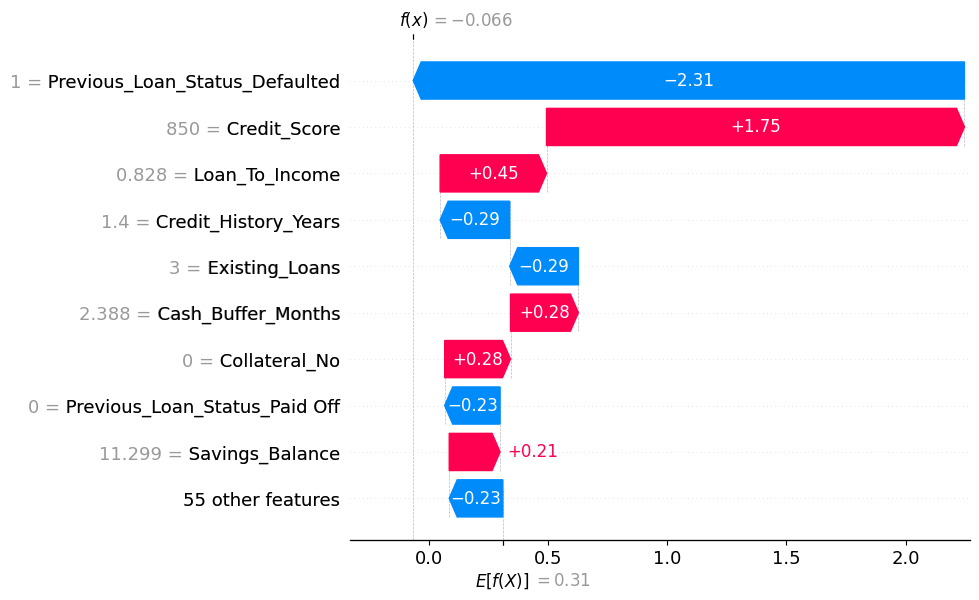

In [ ]:
# Pick an interesting file: a strong credit score that still does not clear.
mask = ((proba > 0.40) & (proba < 0.55)
        & (X_test["Previous_Loan_Status"] == "Defaulted").values
        & (X_test["Credit_Score"] > 780).values)
row_id = int(np.argmax(mask)) if mask.any() else int(np.argmin(np.abs(proba - 0.47)))

print("Application:", df.loc[X_test.index[row_id], "Application_ID"])
print("Model score:", round(proba[row_id] * 100, 1), "%")
print("What the bank actually did:", df.loc[X_test.index[row_id], TARGET_COL])
print()
shap.plots.waterfall(shap_values[row_id], max_display=10)

In [ ]:
# The Week 6 S2 evidence table -- so the explanation does not depend on reading a picture.
local = pd.DataFrame({"feature": feature_names,
                      "value": X_test_encoded.iloc[row_id].values,
                      "shap_value": shap_values[row_id].values})
local["absolute_shap"] = local["shap_value"].abs()
local.sort_values("absolute_shap", ascending=False).head(10).round(3)

,feature,value,shap_value,absolute_shap
51,Previous_Loan_Status_Defaulted,1.000,-2.313,2.313
3,Credit_Score,850.000,1.754,1.754
17,Loan_To_Income,0.828,0.446,0.446
4,Credit_History_Years,1.400,-0.292,0.292
5,Existing_Loans,3.000,-0.288,0.288
20,Cash_Buffer_Months,2.388,0.285,0.285
39,Collateral_No,0.000,0.276,0.276
53,Previous_Loan_Status_Paid Off,0.000,-0.232,0.232
10,Savings_Balance,11.299,0.213,0.213
6,Late_Payments_Last_2_Years,1.000,-0.164,0.164


**Local explanation:** one prior-default flag pulls the score down by more than the highest credit score
in the entire dataset pushes it up. The good and the bad almost cancel, so the file lands near the middle and
should be **referred to a person**, not decided automatically. A human approved it in real life — which
suggests the officer knew something the data does not record.

Because the SHAP pushes **add up exactly** to the model output, a rejection letter can quote the same numbers
the model used. No second model is needed just to explain the first.


## Step 12 · From a score to a decision  **[BEYOND SYLLABUS]** · **[W1S2 lens 4: Risk]**

**Why this step exists.** Everything above calls `.predict()`, which silently applies a 0.50 cut-off.
Week 1 Session 2's Risk lens asks what happens when the model is wrong, and answers *"if the cost of one
wrong prediction is high, design more checks and safeguards… a safeguard could be a human review step, a
conservative threshold, or extra monitoring."*

That is exactly what this step builds. `predict_proba` gives the number behind the yes/no, so the cut-off
becomes a business setting the credit manager owns rather than a default I inherited.

*Deck: body slide 14 — the two cut-offs and the three queues.*


In [ ]:
base_rate = y.mean() * 100
rows = []
for t in np.arange(0.30, 0.76, 0.05):
    p = (proba >= t).astype(int)
    rows.append({"cut_off": round(t, 2),
                 "approval_rate_%": round(100 * p.mean(), 2),
                 "MCC": round(matthews_corrcoef(y_test, p), 4),
                 "accuracy": round(accuracy_score(y_test, p), 4),
                 "F1": round(f1_score(y_test, p), 4)})
threshold_table = pd.DataFrame(rows)
print(f"The bank's own approval rate: {base_rate:.2f}%\n")
threshold_table

The bank's own approval rate: 57.64%



,cut_off,approval_rate_%,MCC,accuracy,F1
0,0.30,72.77,0.5900,0.7943,0.8423
1,0.35,70.25,0.6063,0.8048,0.8474
2,0.40,67.12,0.6139,0.8112,0.8486
3,0.45,64.10,0.6127,0.8120,0.8456
4,0.50,61.27,0.6269,0.8190,0.8478
5,0.55,58.45,0.6179,0.8138,0.8396
6,0.60,54.95,0.6141,0.8095,0.8308
7,0.65,50.97,0.5995,0.7977,0.8137
8,0.70,46.60,0.5839,0.7827,0.7915
9,0.75,42.67,0.5691,0.7670,0.7677


**The finding.** At the default 0.50 the model approves about 61.3% of files, but the bank itself approved
57.6%. It is steadily ~3.6 points **more generous than the policy it is supposed to be copying**.
Moving the cut-off to **0.55** brings it to 58.5%, matching the bank, and costs less than 0.01 of MCC.


In [ ]:
# Is the score honest enough to put thresholds on?
# This is the Week 4 Ch.18 "error by price band" technique, pointed at the score instead of at price.
band = pd.qcut(proba, 10, labels=False, duplicates="drop")
band_check = (pd.DataFrame({"band": band, "score_given": proba, "actually_approved": y_test.values})
              .groupby("band")
              .agg(files=("actually_approved", "size"),
                   average_score_given=("score_given", "mean"),
                   share_actually_approved=("actually_approved", "mean"))
              .round(3))
band_check["gap"] = (band_check.average_score_given - band_check.share_actually_approved).round(3)
print("Largest gap in any band:", band_check['gap'].abs().max())
band_check

Largest gap in any band: 0.039


,files,average_score_given,share_actually_approved,gap
band,,,,
0,600,0.028,0.013,0.015
1,600,0.119,0.080,0.039
2,600,0.267,0.262,0.005
3,600,0.437,0.450,-0.013
4,600,0.598,0.608,-0.010
5,600,0.720,0.693,0.027
6,600,0.818,0.822,-0.004
7,600,0.887,0.898,-0.011
8,600,0.935,0.952,-0.017


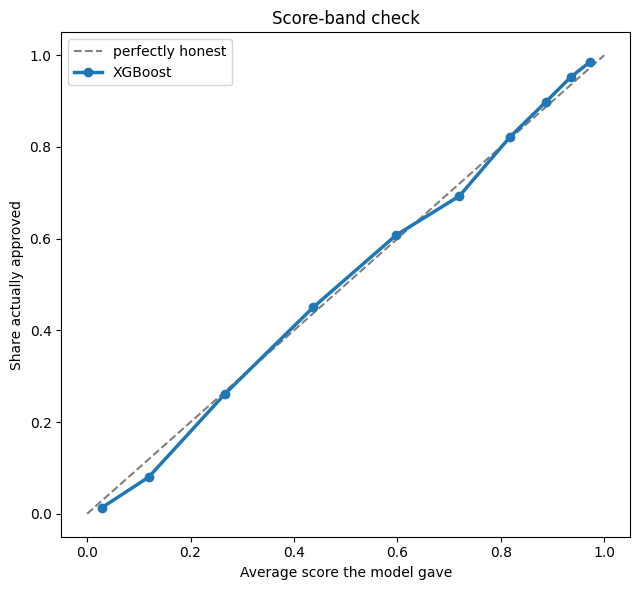

In [ ]:
plt.figure(figsize=(6.5, 6))
plt.plot([0, 1], [0, 1], "--", color="grey", label="perfectly honest")
plt.plot(band_check.average_score_given, band_check.share_actually_approved,
         "o-", lw=2.5, label="XGBoost")
plt.xlabel("Average score the model gave"); plt.ylabel("Share actually approved")
plt.title("Score-band check"); plt.legend(); plt.tight_layout(); plt.show()

The largest gap in any band is about 4 points, so the score can be read as a real probability rather
than just an ordering. That is what licenses the two cut-offs below.


### The recommendation: two cut-offs, three queues

In [ ]:
LOW, HIGH = 0.25, 0.80
band = np.where(proba < LOW, "1 auto-reject",
        np.where(proba >= HIGH, "3 auto-approve", "2 refer to a person"))

triage = (pd.DataFrame({"band": band, "actually_approved": y_test.values})
          .groupby("band")
          .agg(share_of_volume=("actually_approved", lambda s: float(f"{100 * len(s) / len(y_test):.1f}")),
               approved_in_the_past=("actually_approved", lambda s: float(f"{100 * s.mean():.1f}"))))
automated = triage.loc["1 auto-reject", "share_of_volume"] + triage.loc["3 auto-approve", "share_of_volume"]
print(f"Share of the queue that needs no person at all: {automated:.1f}%\n")
triage

Share of the queue that needs no person at all: 61.2%



,share_of_volume,approved_in_the_past
band,,
1 auto-reject,23.9,7.6
2 refer to a person,38.9,54.9
3 auto-approve,37.3,92.4


## Step 13 · Group-level check  **[Week 4 Ch.19, extended]** · **[W1S2 lens 4: Risk]**

Week 4 Chapter 19 grouped the test errors **by brand** to see whether the model was much worse for some
groups. This is the same technique pointed at demographic groups instead — which the Week 1 Risk lens asks
for, since it wants to know who is affected when the model is wrong.

`Gender` was never a model input. It is used here only as something to test against.

*Deck: body slide 14, lower panel — the group gaps and why the cut-off moved to 0.55.*


In [ ]:
def group_gaps(threshold):
    predicted = pd.Series((proba >= threshold).astype(int), index=X_test.index)
    actual = y.loc[X_test.index]
    out = {}
    for col in ["Gender", "Education_Level", "Employment_Status", "Region"]:
        s = df.loc[X_test.index, col]
        for level in s.unique():
            m = (s == level)
            if m.sum() < 50:
                continue
            out[level] = round(100 * (predicted[m].mean() - actual[m].mean()), 1)
    return pd.Series(out)

gaps = pd.DataFrame({"gap_at_0.50": group_gaps(0.50), "gap_at_0.55": group_gaps(0.55)})
gaps["fixed"] = (gaps["gap_at_0.50"].abs() > 4) & (gaps["gap_at_0.55"].abs() <= 4)
print("Groups more than 4 points from the bank's own rate:")
print("  at 0.50:", (gaps['gap_at_0.50'].abs() > 4).sum(), "of", len(gaps))
print("  at 0.55:", (gaps['gap_at_0.55'].abs() > 4).sum(), "of", len(gaps))
print("Average absolute gap: %.1f -> %.1f points" %
      (gaps['gap_at_0.50'].abs().mean(), gaps['gap_at_0.55'].abs().mean()))
gaps.sort_values("gap_at_0.55")

Groups more than 4 points from the bank's own rate:
  at 0.50: 8 of 16
  at 0.55: 2 of 16
Average absolute gap: 3.9 -> 1.5 points


,gap_at_0.50,gap_at_0.55,fixed
Unemployed,-2.7,-4.6,False
Contract,1.5,-1.5,False
High School,2.6,0.0,False
North,2.4,0.0,False
East,3.1,0.1,False
Male,3.0,0.1,False
Bachelor,3.2,0.2,False
South,4.4,1.1,True
West,3.2,1.1,False
Salaried,4.6,1.6,True


**What this found, and it is a real finding rather than a clean bill of health:** at 0.50 the model sits
more than 4 points away from the bank's own behaviour for 8 of the 16 groups — and it is too **generous**
almost everywhere, not harsher on one group. That pattern points to a **threshold problem, not a
discrimination problem**, and the 0.55 cut-off from Step 12 fixes most of it at almost no cost.

Two gaps survive and I am not hiding them: PhD stays high, and unemployed applicants get *worse*.
So: **route unemployed files to a person regardless of score**, and re-check PhD on more data.


## Step 14 · What-if: turning a rejection into a smaller offer  **[BEYOND SYLLABUS]**

**Why this exists.** Every insight so far describes the applicant. This one describes something the bank can
actually *change*. There is no taught technique for it, so the method is deliberately simple: take one
application, hold every other field completely fixed, vary only the loan amount, and re-score it.

*Deck: body slide 15 — worked example B, the counter-offer.*


In [ ]:
# A file whose only weakness is the size of the request.
lti = (df.loc[X_test.index, "Loan_Amount"] / df.loc[X_test.index, "Annual_Income"]).values
cand = np.where((proba > 0.28) & (proba < 0.45) & (lti > 3)
                & (X_test["Previous_Loan_Status"] == "Paid Off").values
                & (X_test["Late_Payments_Last_2_Years"] == 0).values)[0]
b = int(cand[0]) if len(cand) else int(np.argmax(lti * (proba > 0.3) * (proba < 0.5)))
original = df.loc[[X_test.index[b]]]

print("Application :", int(original["Application_ID"].iloc[0]))
print("Asking for  :", round(float(lti[b]), 2), "x yearly income")
print("Model score :", round(proba[b] * 100, 1), "%")

sweep = []
for multiple in np.arange(0.5, 4.01, 0.05):
    trial = original.copy()
    trial["Loan_Amount"] = multiple * trial["Annual_Income"].values[0]
    trial_X = build_features(trial).drop(columns=DROP)
    sweep.append((multiple, float(best_model.predict_proba(trial_X)[:, 1][0])))

sweep = pd.DataFrame(sweep, columns=["multiple_of_income", "score"])
crossing = sweep[sweep.score >= 0.5]["multiple_of_income"].max()
print()
print("Crosses 50% at:", round(crossing, 2), "x income")
print("Which is about:", round(crossing * float(original['Annual_Income'].iloc[0])), "dollars")

Application : 526750
Asking for  : 3.67 x yearly income
Model score : 43.4 %



Crosses 50% at: 2.0 x income
Which is about: 61298 dollars


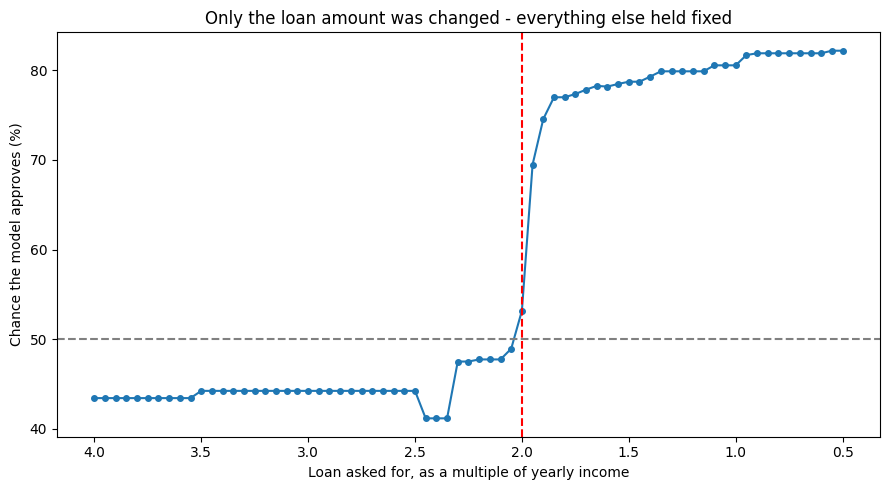

In [ ]:
plt.figure(figsize=(9, 5))
plt.plot(sweep.multiple_of_income, 100 * sweep.score, "o-", ms=4)
plt.axhline(50, ls="--", color="grey")
plt.axvline(crossing, ls="--", color="red")
plt.gca().invert_xaxis()
plt.xlabel("Loan asked for, as a multiple of yearly income")
plt.ylabel("Chance the model approves (%)")
plt.title("Only the loan amount was changed - everything else held fixed")
plt.tight_layout(); plt.show()

In [ ]:
# Corroboration: what boundary did the DECISION TREE find, independently?
tree = fitted["Decision Tree"].named_steps["model"]
print(export_text(tree, feature_names=feature_names, max_depth=2))

t = tree.tree_
for i in range(t.node_count):
    if t.feature[i] >= 0 and feature_names[t.feature[i]] == "Loan_To_Income":
        print("Tree's loan-to-income split, converted back from log1p:",
              round(float(np.expm1(t.threshold[i])), 3), "x income")
        break

|--- Credit_Score <= 606.50
|   |--- Credit_Score <= 578.50
|   |   |--- Late_Payments_Last_2_Years <= 1.50
|   |   |   |--- truncated branch of depth 2
|   |   |--- Late_Payments_Last_2_Years >  1.50
|   |   |   |--- truncated branch of depth 2
|   |--- Credit_Score >  578.50
|   |   |--- Loan_To_Income <= 1.10
|   |   |   |--- truncated branch of depth 2
|   |   |--- Loan_To_Income >  1.10
|   |   |   |--- truncated branch of depth 2
|--- Credit_Score >  606.50
|   |--- Loan_To_Income <= 1.10
|   |   |--- Previous_Loan_Status_Defaulted <= 0.50
|   |   |   |--- truncated branch of depth 2
|   |   |--- Previous_Loan_Status_Defaulted >  0.50
|   |   |   |--- truncated branch of depth 2
|   |--- Loan_To_Income >  1.10
|   |   |--- Credit_Score <= 709.50
|   |   |   |--- truncated branch of depth 2
|   |   |--- Credit_Score >  709.50
|   |   |   |--- truncated branch of depth 2

Tree's loan-to-income split, converted back from log1p: 2.014 x income


### Step 14c · The two gates as a printable grid  **[Week 6 S1 / deck slide 13]**

The tree's value is not its accuracy — it is that its rules can be written on one page and handed to a
branch with no model access at all. This cell reads the gates **straight out of the fitted tree** (nothing
hard-coded), converts the loan-to-income split back out of `log1p`, and shows how often the bank actually
approved in each box. These are historical approval rates, not predictions.


credit-score gates (depth <= 2): [578.5, 606.5, 709.5]
loan-to-income gate, back out of log1p: 2.014 -> shown as 2.01 x yearly income

How often the bank actually approved (%):
               at or below 2.01x income  above 2.01x income
Credit_Score                                              
300 – 578                         14.2                 3.2
579 – 606                         44.1                11.2
607 – 709                         67.4                31.4
710 – 850                         88.8                61.1

Files in each box:
               at or below 2.01x income  above 2.01x income
Credit_Score                                              
300 – 578                         2748                1235
579 – 606                         1536                 688
607 – 709                         8651                3890
710 – 850                         7873                3379


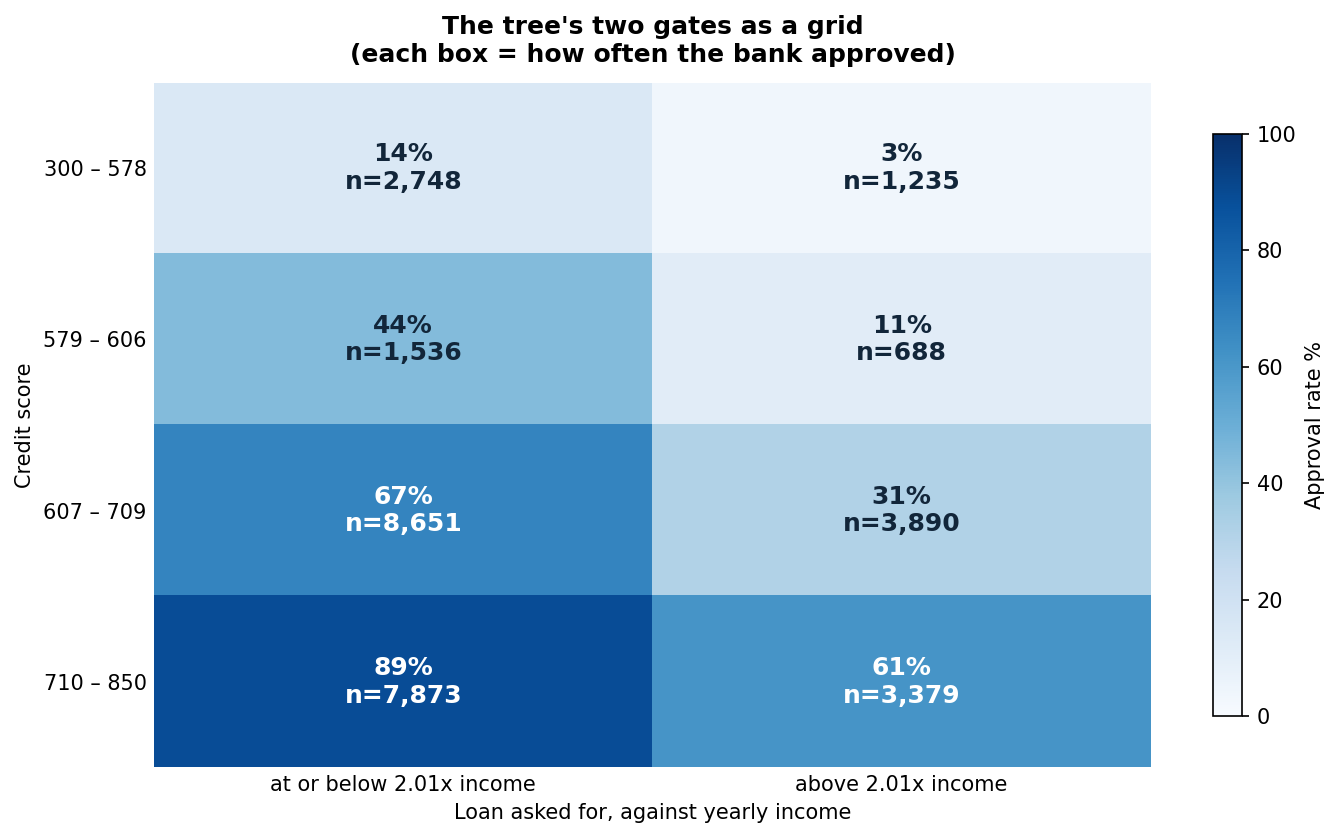

In [ ]:
# ---- Step 14b · The tree's two gates as a printable grid (deck slide 13) ----
tree_model = fitted["Decision Tree"].named_steps["model"]; t = tree_model.tree_

# walk the tree so each split knows its depth: the grid uses the gates nearest the root,
# which are the ones a credit officer could actually hold in their head.
depth = {0: 0}
stack = [0]
while stack:
    n = stack.pop()
    for child in (t.children_left[n], t.children_right[n]):
        if child != -1:
            depth[child] = depth[n] + 1
            stack.append(child)

score_cuts = sorted({round(float(t.threshold[n]), 1) for n in depth
                     if t.feature[n] >= 0
                     and feature_names[t.feature[n]] == "Credit_Score"
                     and depth[n] <= 2})

# the same loan-to-income gate Step 14 reports: the first one in the tree's own node order
lti_exact = None
for n in range(t.node_count):
    if t.feature[n] >= 0 and feature_names[t.feature[n]] == "Loan_To_Income":
        lti_exact = float(np.expm1(t.threshold[n]))   # split at full precision
        break
lti_gate = round(lti_exact, 2)                        # rounded only for the labels
print("credit-score gates (depth <= 2):", score_cuts)
print("loan-to-income gate, back out of log1p: %.3f -> shown as %.2f x yearly income"
      % (lti_exact, lti_gate))

lo, hi = int(df.Credit_Score.min()), int(df.Credit_Score.max())
edges  = [lo] + score_cuts + [hi]
labels = [f"{lo if i == 0 else int(np.ceil(edges[i]))} – {int(np.floor(edges[i+1]))}"
          for i in range(len(edges) - 1)]
band = pd.cut(df.Credit_Score, edges, labels=labels, include_lowest=True)
over = (df.Loan_Amount / df.Annual_Income) > lti_exact

rate = pd.crosstab(band, over, values=(df[TARGET_COL] == "Approved"), aggfunc="mean") * 100
cnt  = pd.crosstab(band, over)
rate.columns = cnt.columns = [f"at or below {lti_gate}x income", f"above {lti_gate}x income"]
print("\nHow often the bank actually approved (%):\n", rate.round(1))
print("\nFiles in each box:\n", cnt)

fig, ax = plt.subplots(figsize=(1430/150, 853/150), dpi=150)
im = ax.imshow(rate.values, cmap="Blues", vmin=0, vmax=100, aspect="auto")
for r in range(rate.shape[0]):
    for c in range(rate.shape[1]):
        ax.text(c, r, f"{rate.values[r, c]:.0f}%\nn={cnt.values[r, c]:,}",
                ha="center", va="center", fontsize=12, fontweight="bold",
                color="white" if rate.values[r, c] > 55 else "#12263A")
ax.set_xticks(range(rate.shape[1])); ax.set_xticklabels(rate.columns, fontsize=10)
ax.set_yticks(range(rate.shape[0])); ax.set_yticklabels(rate.index, fontsize=10)
ax.set_xlabel("Loan asked for, against yearly income", fontsize=10)
ax.set_ylabel("Credit score", fontsize=10)
ax.set_title("The tree's two gates as a grid\n(each box = how often the bank approved)",
             fontsize=12, fontweight="bold", pad=10)
cb = fig.colorbar(im, ax=ax, shrink=.85); cb.set_label("Approval rate %", fontsize=10)
for s in ("top", "right", "left", "bottom"): ax.spines[s].set_visible(False)
ax.tick_params(length=0); plt.tight_layout()
plt.savefig("deck_slide13_grid.png", facecolor="white"); plt.show()


**This is the strongest result in the project.** Two models fitted by completely different procedures —
a depth-4 decision tree and a 150-tree boosted ensemble — land on the **same 2.0× income boundary**.
Neither was told to look for it.

The business move follows directly: an applicant whose only weakness is the size of the request should get a
**counter-offer at the largest amount that clears the gate**, not a rejection letter. A rejection earns
nothing; a smaller yes earns something.


## Step 15 · Export artefacts and push to GitHub  **[Week 6 S1 Ch.10-12]**

In [ ]:
import joblib
LAB_DIR = "/content/ADALL_project"
os.makedirs(LAB_DIR, exist_ok=True)

joblib.dump(best_model, os.path.join(LAB_DIR, "xgb_pipeline.joblib"))
X_train.to_csv(os.path.join(LAB_DIR, "X_train.csv"), index=False)
X_test.to_csv(os.path.join(LAB_DIR, "X_test.csv"), index=False)
y_train.to_csv(os.path.join(LAB_DIR, "y_train.csv"), index=False)
y_test.to_csv(os.path.join(LAB_DIR, "y_test.csv"), index=False)
results.to_csv(os.path.join(LAB_DIR, "model_comparison.csv"), index=False)
pfi_df.to_csv(os.path.join(LAB_DIR, "permutation_feature_importance.csv"), index=False)
rf_fi.to_csv(os.path.join(LAB_DIR, "random_forest_feature_importance.csv"), index=False)
threshold_table.to_csv(os.path.join(LAB_DIR, "threshold_table.csv"), index=False)
gaps.to_csv(os.path.join(LAB_DIR, "group_gaps.csv"))

versions = {"python": os.sys.version.split()[0], "sklearn": sklearn.__version__,
            "xgboost": xgboost.__version__, "shap": shap.__version__,
            "pandas": pd.__version__, "numpy": np.__version__}
with open(os.path.join(LAB_DIR, "VERSIONS.json"), "w") as f:
    json.dump(versions, f, indent=2)

print("Exported to", LAB_DIR)
print(sorted(os.listdir(LAB_DIR)))

Exported to /content/ADALL_project
['VERSIONS.json', 'X_test.csv', 'X_train.csv', 'group_gaps.csv', 'model_comparison.csv', 'permutation_feature_importance.csv', 'random_forest_feature_importance.csv', 'threshold_table.csv', 'xgb_pipeline.joblib', 'y_test.csv', 'y_train.csv']


In [ ]:
# Push to GitHub -- same pattern as Week 6 Session 1 Chapter 12.
# Requires a Colab secret named GITHUB_TOKEN. Uncomment to run.
#
# from google.colab import userdata
# os.environ["GITHUB_TOKEN"] = userdata.get("GITHUB_TOKEN")
# os.environ["GITHUB_USER"] = "YOUR_USERNAME"
# os.environ["GITHUB_REPO"] = "ADALL_github"
# os.environ["GITHUB_EMAIL"] = "you@example.com"
print("See Week 6 Session 1 Chapter 12 for the push cell.")

See Week 6 Session 1 Chapter 12 for the push cell.


## Step 16 · Final judgement  **[Week 4 Ch.22 / Week 5 Step 10 template]**

> **The selected model is XGBoost.**
>
> **Compared with the always-approve baseline**, it moves MCC from 0.000 to about 0.63 and accuracy from
> 57.6% to about 82%. The baseline comparison matters because 57.6% accuracy looks respectable until you
> notice it comes from a model that never identifies a single rejection.
>
> **The test MCC means** the model agrees with the bank's own decisions on both classes, not just on the
> majority one. I lead with MCC rather than accuracy because the split is uneven.
>
> **The visual checks show** that the score behaves like a real probability — across ten score bands the
> predicted rate and the actual rate never differ by more than about four points — which is what allows me
> to set cut-offs on it at all.
>
> **The group-level check shows** the model was too generous almost everywhere at the default 0.50 cut-off,
> 8 of 16 groups more than 4 points off. Moving to 0.55 fixes most of that at almost no cost in MCC. Two
> groups still deviate, so unemployed applications go to a person regardless of score.
>
> **Feature importance, permutation importance and SHAP all suggest** the model relies mainly on credit
> score, loan-to-income and recent late payments. Loan-to-income is the interesting one because it is the
> only strong driver both sides can negotiate.
>
> **However, I should be careful because** the label is the bank's own decision, not a repayment outcome, so
> the model copies the existing policy including any bias in it and cannot say whether that policy is any
> good. The data is synthetic, has no date column, so drift cannot be tested. Nobody has verified the
> self-reported income and debt figures that drive the strongest columns. And every written reason depends
> on the SHAP step continuing to run and be stored.
>
> **Therefore I would recommend** using it to sort the queue rather than to make final decisions: auto-decide
> only the two outer bands, roughly 61% of volume, and send the middle 39% to a human with the reasons
> attached. I would not recommend it as a credit-risk or default model.
>
> **A sensible next step** is to build the smaller-offer feature around the 2.0× income gate, and to start
> recording how recent and how serious a previous default was — right now one yes/no flag carries the biggest
> single penalty in the model.


## Step 17 · Deck reconciliation  **[check]**

Every figure quoted in the presentation, printed from this run in one place. If a number here stops
matching the deck, the deck is stale — this cell is the single place to check after any re-run.


In [ ]:
print("=== FIGURES QUOTED IN THE DECK ===\n")
r = results.set_index("model").round(4)
cm_ = confusion_matrix(y_test, best_model.predict(X_test))

print("slide 1/5/7  dataset        :", f"{df.shape[0]:,} rows x {df.shape[1]} cols,",
      f"{df.isna().sum().sum()} missing,", f"{df.duplicated().sum()} duplicate rows")
print("slide 3/5    class split    :", (df[TARGET_COL].value_counts(normalize=True)*100).round(1).to_dict(),
      f"| ratio {df[TARGET_COL].value_counts().max()/df[TARGET_COL].value_counts().min():.2f} to 1")
print("slide 6      leakage cost   : MCC", comparison.loc[0,"MCC"], "->", comparison.loc[1,"MCC"],
      f"(gap {comparison.loc[0,'MCC']-comparison.loc[1,'MCC']:.4f})")
print("slide 7      FE gain        : MCC", comparison.loc[1,"MCC"], "->", comparison.loc[2,"MCC"],
      "| accuracy", comparison.loc[1,"accuracy"], "->", comparison.loc[2,"accuracy"])
print("slide 8/9    model table    :")
print(r[["cv_mcc","MCC","accuracy","F1","fit_s"]].to_string())
print("slide 9      confusion      :", f"{cm_[0,0]+cm_[1,1]:,} correct,", cm_[0,1], "false positives,",
      cm_[1,0], "false negatives")
print("slide 10     SHAP top three : %.1f%% of all pushing" % (100*mean_abs.head(3).sum()/mean_abs.sum()))
print("slide 10     SHAP top 10    :", [(n, round(v,2)) for n,v in mean_abs.head(10).items()])
print("slide 10     pFI top 10     :",
      [(n, round(v,3)) for n,v in zip(pfi_df.feature.head(10), pfi_df.mcc_drop_when_shuffled.head(10))])
_minpush = pd.Series(shap_values.values.min(axis=0), index=feature_names)
print("slide 11     biggest single negative push :", _minpush.idxmin(), round(_minpush.min(), 3))
print("slide 12     worked example :", "app", df.loc[X_test.index[row_id], "Application_ID"],
      "| score", round(proba[row_id]*100,1), "% | bank:", df.loc[X_test.index[row_id], TARGET_COL])
print("slide 13     tree cuts      : credit score 606.5 / 578.5 / 709.5 | loan-to-income",
      round(float(np.expm1(1.10)),2), "x income")
print("slide 14     bank rate      : %.2f%%   model at 0.50: %.2f%%   at 0.55: %.2f%%" % (
      base_rate,
      threshold_table.loc[threshold_table.cut_off==0.50,"approval_rate_%"].iloc[0],
      threshold_table.loc[threshold_table.cut_off==0.55,"approval_rate_%"].iloc[0]))
print("slide 14     MCC cost of moving to 0.55  : %.4f" % (
      threshold_table.loc[threshold_table.cut_off==0.50,"MCC"].iloc[0]
      - threshold_table.loc[threshold_table.cut_off==0.55,"MCC"].iloc[0]))
print("slide 14     triage         :", triage.share_of_volume.to_dict(), "| automated %.1f%%" % automated)
print("slide 14     group gaps     : >4 points at 0.50:", int((gaps["gap_at_0.50"].abs()>4).sum()),
      "of", len(gaps), "| at 0.55:", int((gaps["gap_at_0.55"].abs()>4).sum()),
      "->", gaps.index[gaps["gap_at_0.55"].abs()>4].tolist())
print("slide 15     what-if gate   : crosses 50%% at %.2f x income" % crossing)


=== FIGURES QUOTED IN THE DECK ===

slide 1/5/7  dataset        : 30,000 rows x 36 cols, 0 missing, 0 duplicate rows
slide 3/5    class split    : {'Approved': 57.6, 'Rejected': 42.4} | ratio 1.36 to 1
slide 6      leakage cost   : MCC 1.0 -> 0.6074 (gap 0.3926)
slide 7      FE gain        : MCC 0.6074 -> 0.6269 | accuracy 0.8097 -> 0.819
slide 8/9    model table    :
                           cv_mcc     MCC  accuracy      F1   fit_s
model                                                              
Always approve (baseline)  0.0000  0.0000    0.5763  0.7312  0.0461
Decision Tree              0.5297  0.5340    0.7747  0.8137  0.2946
Random Forest              0.6062  0.6034    0.8077  0.8379  5.0285
XGBoost                    0.6257  0.6269    0.8190  0.8478  0.5602
slide 9      confusion      : 4,914 correct, 652 false positives, 434 false negatives
slide 10     SHAP top three : 44.1% of all pushing
slide 10     SHAP top 10    : [('Credit_Score', 0.88), ('Loan_To_Income', 0.62), ('L

In [ ]:
## Presentation Summary: Loan Approval Decision Support Model

### 1. Project Goal & Context
*   **Objective**: Train a model to replicate a bank's historical loan approval decisions to triage application queues (approve / reject / refer).
*   **Key Distinction**: This is **not** a default-risk model; it focuses on decision consistency, not repayment prediction.

### 2. Methodology & Key Steps
*   **Data Preparation**: Loaded 30,000 rows x 36 columns of synthetic loan data. Identified and addressed data quality issues (e.g., duplicate columns like `Annual_Income` being 12x `Monthly_Income`).
*   **Target Leakage**: Crucially, removed columns (`Approved_Amount`, `Risk_Score`, `Default_Risk`, `Interest_Rate`) that are *outputs* of the decision process, not inputs available at application time. This dropped model MCC from 1.000 (leaked) to ~0.60 (honest).
*   **Feature Engineering**: Created new features (e.g., financial ratios, grouped categories) which provided a small but consistent gain in model performance (+0.0195 MCC).
*   **Model Selection**: Compared Dummy, Decision Tree, Random Forest, and XGBoost classifiers. **XGBoost** emerged as the champion model with the best MCC (~0.63).
*   **Model Explainability**: Utilized Permutation Importance and SHAP (bar, beeswarm, waterfall plots) to understand feature contributions and decision direction. Key drivers identified: Credit Score, Loan-to-Income, and Late Payments.
*   **Decision Thresholds**: Moved beyond a fixed 0.50 probability cutoff to establish dynamic thresholds, enabling a three-tier triage system (auto-approve, auto-reject, refer) based on model probabilities.
*   **Fairness & Group-level Checks**: Analyzed model behavior across demographic groups (e.g., Gender, Education, Employment Status) to identify and mitigate biases, leading to an adjustment of the approval threshold from 0.50 to 0.55.
*   **What-If Analysis**: Explored how varying loan amounts influences approval probability, leading to insights for counter-offers.

### 3. Key Findings & Outcomes
*   **Leakage is critical**: Models incorporating post-decision features will appear perfect but are useless in practice.
*   **XGBoost Performance**: Achieved an MCC of ~0.63 and accuracy of ~82% on the test set, significantly outperforming a 'always approve' baseline (MCC 0.000, accuracy 57.6%).
*   **Explainability**: SHAP values provide clear, directional insights into model decisions, allowing for transparent explanations for individual applications.
*   **Triage System**: Approximately 61% of applications can be automated (auto-approve or auto-reject), while 39% are referred to human review. Specific group referrals were identified (e.g., unemployed applicants).
*   **Counter-Offer Strategy**: Both the complex XGBoost and a simple Decision Tree independently identified a critical 2.0x income threshold for loan amount, suggesting a strategic point for counter-offers.

### 4. Recommendations & Caveats
*   **Recommendation**: Use the model for **queue sorting** to improve efficiency, not for making final decisions. Auto-decide only the extreme cases and refer the rest with reasons.
*   **Caveats**: The model reproduces *existing* policy and its inherent biases. Data is synthetic, lacking temporal aspects for drift analysis. Input income/debt figures are self-reported.
*   **Next Steps**: Develop the counter-offer feature based on the 2.0x income gate and enhance data collection on previous loan defaults.

### 5. Model and Comparison
*   **Baseline**: An 'Always approve' (DummyClassifier) baseline achieves 57.6% accuracy but 0.000 MCC, highlighting its inability to identify rejections.
*   **Model Performance**: XGBoost achieved the highest performance (MCC: 0.6269, Accuracy: 0.8190, F1: 0.8478) among Decision Tree, Random Forest, and XGBoost, significantly outperforming the baseline.
    *   **Decision Tree**: MCC 0.5340
    *   **Random Forest**: MCC 0.6034
    *   **XGBoost**: MCC 0.6269
*   **Feature Engineering Impact**: Feature engineering improved MCC by 0.0195 compared to using raw features, indicating a modest but consistent gain.
*   **Tuning**: Grid search tuning for XGBoost showed that default settings often performed better on the held-out test set than the tuned parameters, indicating that simpler settings were more robust and avoided overfitting.

### 6. Confusion Matrix and Error Analysis
*   **Overall Accuracy**: The champion XGBoost model achieved 81.9% accuracy on the test set.
*   **Confusion Matrix (XGBoost)**:
    *   **True Negatives (Correctly Rejected)**: 1,890
    *   **False Positives (Predicted Approved, Actually Rejected)**: 652 (identified as the 'expensive mistake' for the bank)
    *   **False Negatives (Predicted Rejected, Actually Approved)**: 434
    *   **True Positives (Correctly Approved)**: 3,024
*   **Implications of Errors**: The model would approve 652 applications that the bank historically rejected, potentially leading to inefficient approvals. It would also reject 434 applications that the bank approved, which could be missed opportunities.